In [13]:
import pandas as pd 
import requests
import time
import os
import numpy as np
import py3Dmol
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
import matplotlib.pyplot as plt
import seaborn as sns




In [14]:
overall_data = "/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/IEDB_ML_ready.csv"
overall_df = pd.read_csv(overall_data)



print(overall_df.head())

# print(overall_df['source'].value_counts())


  Peptide Sequence Best HLA Allele Tissue                   Disease  length  \
0        KYARVVQKL     HLA-A*24:02   PBMC                   healthy       9   
1        ALLETVNRL     HLA-A*02:01   PBMC                   healthy       9   
2        MGLLPGALL     HLA-B*14:02   SKIN                   healthy       9   
3        LADAINTEF     HLA-A*32:01   PBMC    acute myeloid leukemia       9   
4       ILEEGKEILV     HLA-A*02:01   PBMC  chronic myeloid leukemia      10   

   molecular_weight  charge_pH_7  hydrophobicity_GRAVY  isoelectric_point  \
0         1104.3455     2.757095             -0.344444          10.289686   
1         1028.2032    -0.201325              0.577778           6.047009   
2          884.1374    -0.499645              1.833333           5.275022   
3          993.0680    -2.235967              0.388889           4.050028   
4         1142.3423    -2.232466              0.600000           4.252659   

   oxidation_flag  ...   aa_pct_N   aa_pct_P   aa_pct_Q   aa_p

In [15]:
AA_COLS = [f"aa_pct_{aa}" for aa in "ACDEFGHIKLMNPQRSTVWY"]
DROP_ZERO_VAR = ["has_modification", "oxidation_flag"]
CLIP_COLS = ["instability_index", "aliphatic_index"]
CLIP_PERCENTILE = 0.99

n0 = len(overall_df)

to_drop = [c for c in DROP_ZERO_VAR if c in overall_df.columns]
overall_df = overall_df.drop(columns=to_drop)



if "flexibility_mean" in overall_df.columns:
        pct_missing = overall_df["flexibility_mean"].isnull().mean() * 100
        overall_df = overall_df.drop(columns=["flexibility_mean"])
        print(f"[2] Dropped flexibility_mean ({pct_missing:.1f}% missing)")
else:
        print("[2] flexibility_mean not found — skipping")


present_aa = [c for c in AA_COLS if c in overall_df.columns]

if present_aa:
    sample_max = overall_df[present_aa].max().max()
    if sample_max > 1.5:   # only divide if they're still in 0-100 range
        overall_df[present_aa] = overall_df[present_aa] / 100.0
        print(f"[3] Divided {len(present_aa)} aa_pct_* columns by 100  "
            f"(was 0-{sample_max:.1f}, now 0-1)")
    else:
        print(f"[3] aa_pct_* already in 0-1 range — skipping")

for col in CLIP_COLS:
    if col in overall_df.columns:
        cap = overall_df[col].quantile(CLIP_PERCENTILE)
        n_clipped = (overall_df[col] > cap).sum()
        overall_df[col] = overall_df[col].clip(upper=cap)
        print(f"[4] Clipped {col} at {CLIP_PERCENTILE:.0%} percentile "
            f"({cap:.2f}), affected {n_clipped:,} rows")


n_before = len(overall_df)
overall_df = overall_df.drop_duplicates(subset=["Peptide Sequence", "Tissue", "is_cancer"])
n_removed = n_before - len(overall_df)
print(f"[5] Removed {n_removed:,} exact duplicate rows "
    f"({100*n_removed/n_before:.1f}%) → {len(overall_df):,} rows remaining")


healthy_seqs = set(overall_df.loc[overall_df["is_cancer"] == 0, "Peptide Sequence"])
overall_df["found_in_healthy"] = overall_df["Peptide Sequence"].isin(healthy_seqs).astype(int)
cancer_also_healthy = (
    (overall_df["is_cancer"] == 1) & (overall_df["found_in_healthy"] == 1)
).sum()
print(f"[6] Added found_in_healthy flag "
      f"({cancer_also_healthy:,} cancer rows also seen in healthy tissue)")


overall_df["strat_key"] = (
        overall_df["is_cancer"].astype(int).astype(str) + "_" +
        overall_df["length"].astype(str)
    )
print(f"[7] Added strat_key column for stratified splitting:")
for key, count in overall_df["strat_key"].value_counts().sort_index().items():
        print(f"    {key}: {count:,} rows")

print(f"\n{'='*50}")
print(f"FINAL DATASET SUMMARY")
print(f"{'='*50}")
print(f"Rows:     {n0:,}  →  {len(overall_df):,}  (-{n0-len(overall_df):,})")
print(f"Columns:  {n0}  →  {len(overall_df.columns)}")
print(f"\nLabel balance:")
vc = overall_df["is_cancer"].value_counts().sort_index()
for label, count in vc.items():
    tag = "healthy" if label == 0 else "cancer "
    print(f"  {tag} ({int(label)}): {count:,}  ({100*count/len(overall_df):.1f}%)")

print(f"\nLength distribution:")
for length, count in overall_df["length"].value_counts().sort_index().items():
    cancer = (overall_df[overall_df["length"] == length]["is_cancer"] == 1).sum()
    healthy = count - cancer
    print(f"  {length}-mer: {count:,} total  "
        f"(cancer={cancer:,}, healthy={healthy:,})")

print(f"\nFeature scale check (aa_pct_A should now be 0-1):")
if "aa_pct_A" in overall_df.columns:
    print(f"  aa_pct_A max = {overall_df['aa_pct_A'].max():.4f}  "
        f"(target: ≤ 1.0)")


[2] Dropped flexibility_mean (80.7% missing)
[3] Divided 20 aa_pct_* columns by 100  (was 0-100.0, now 0-1)
[4] Clipped instability_index at 99% percentile (143.31), affected 588 rows
[4] Clipped aliphatic_index at 99% percentile (216.67), affected 387 rows
[5] Removed 10,748 exact duplicate rows (17.2%) → 51,788 rows remaining
[6] Added found_in_healthy flag (4,084 cancer rows also seen in healthy tissue)
[7] Added strat_key column for stratified splitting:
    0_10: 6,775 rows
    0_9: 21,792 rows
    1_10: 4,389 rows
    1_9: 18,832 rows

FINAL DATASET SUMMARY
Rows:     62,536  →  51,788  (-10,748)
Columns:  62536  →  50

Label balance:
  healthy (0): 28,567  (55.2%)
  cancer  (1): 23,221  (44.8%)

Length distribution:
  9-mer: 40,624 total  (cancer=18,832, healthy=21,792)
  10-mer: 11,164 total  (cancer=4,389, healthy=6,775)

Feature scale check (aa_pct_A should now be 0-1):
  aa_pct_A max = 1.0000  (target: ≤ 1.0)


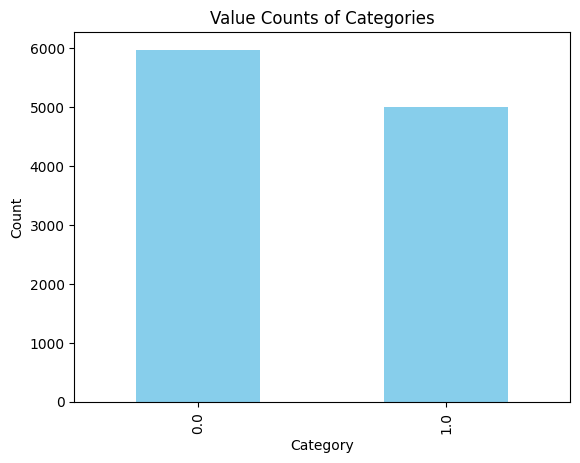

In [9]:
tissue_counts = overall_df['is_cancer'].value_counts()
tissue_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Value Counts of Categories')
plt.show()


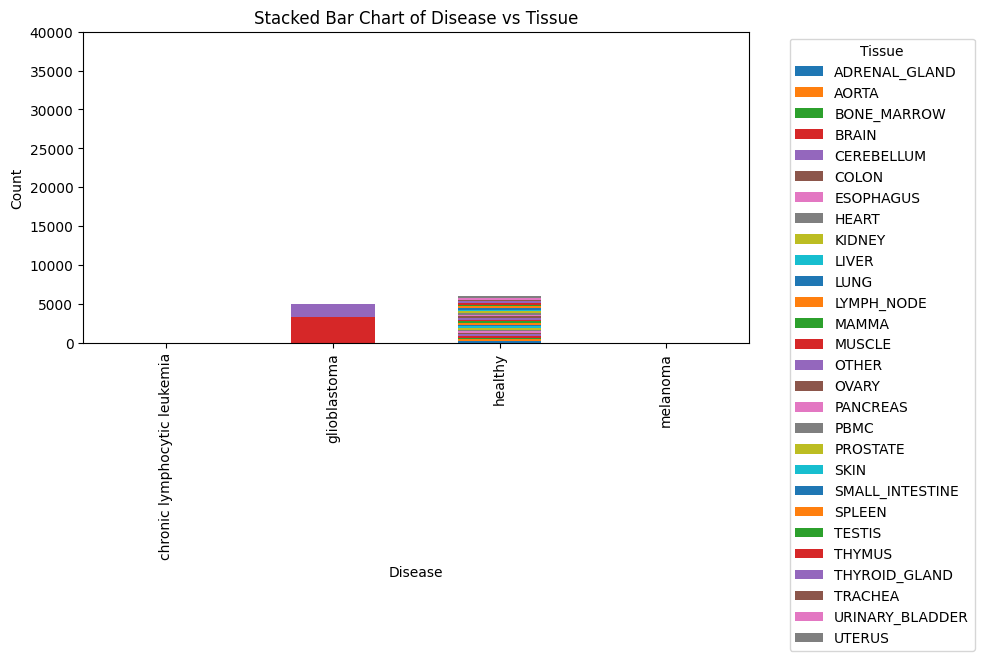

In [10]:
pd.crosstab(overall_df['Disease'], overall_df['Tissue']).sort_index(axis=0, ascending=True).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Disease')
plt.ylabel('Count')
plt.ylim(0,40000)
plt.title('Stacked Bar Chart of Disease vs Tissue')
plt.legend(title='Tissue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Percentage of Peptides by Length:
        Healthy (0) %  Cancer (1) %
length                             
9               76.28          81.1
10              23.72          18.9
--------------------------------------------------


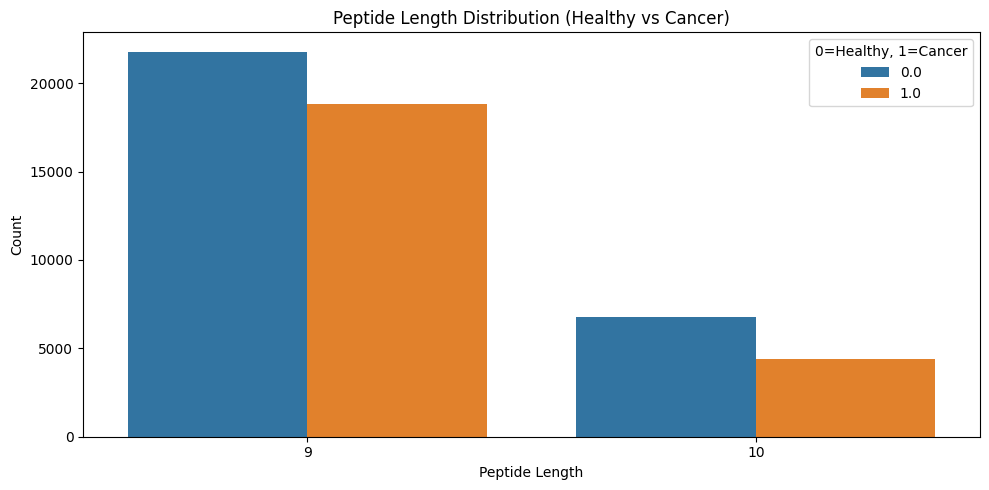

2. HLA ALLELE LEAKAGE CHECK (Top 15 Alleles)
                 Healthy (0)  Cancer (1)  Total  Cancer %
Best HLA Allele                                          
HLA-A*02:01             3383        3118   6501      48.0
HLA-A*24:02              673        1994   2667      74.8
HLA-B*07:02             2146         178   2324       7.7
HLA-B*44:02              694        1528   2222      68.8
HLA-B*44:03              618        1602   2220      72.2
HLA-A*11:01             1590         471   2061      22.9
HLA-B*27:05             1899          23   1922       1.2
HLA-B*15:01             1767          14   1781       0.8
HLA-B*40:02             1131         549   1680      32.7
HLA-A*01:01             1370         226   1596      14.2
HLA-A*30:01                8        1504   1512      99.5
HLA-B*15:10                1        1470   1471      99.9
HLA-B*18:01               43        1396   1439      97.0
HLA-A*03:01             1143         152   1295      11.7
HLA-A*25:01                

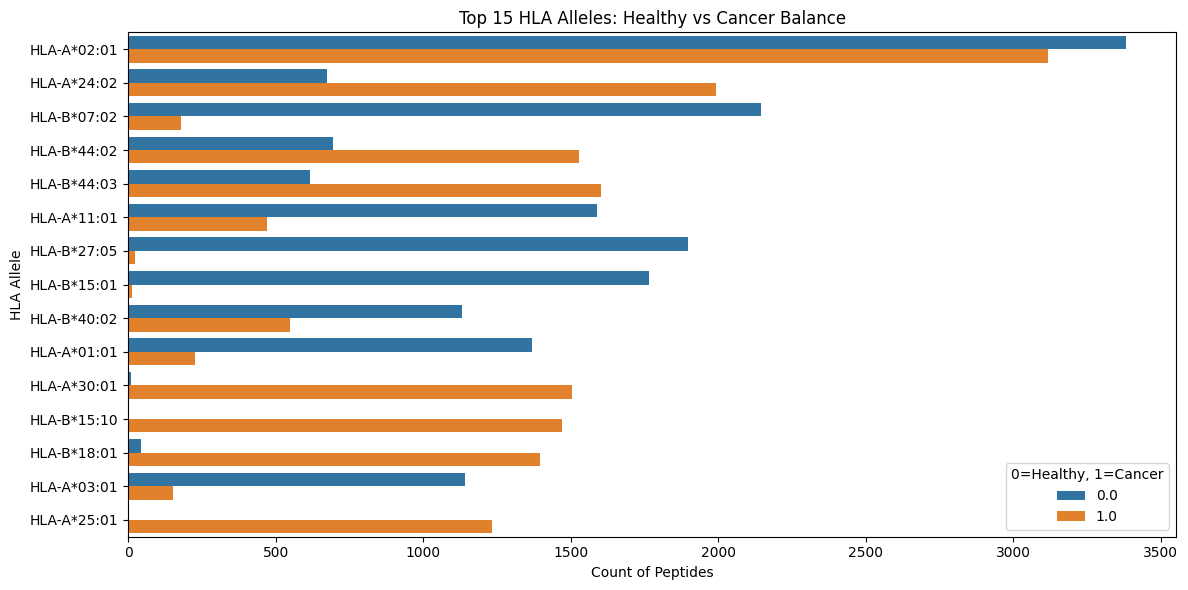


3. CANCER DISEASE BREAKDOWN BY LENGTH
length                      9     10
Disease                             
acute myeloid leukemia    3455   574
chronic myeloid leukemia  3648   478
glioblastoma              1998   442
lung adenocarcinoma       3646  1252
melanoma                  3484  1135
multiple myeloma           438    83
renal cell carcinoma      1746   323


In [16]:

# Create a cross-tabulation of length vs is_cancer
length_ct = pd.crosstab(overall_df['length'], overall_df['is_cancer'], normalize='columns') * 100
length_ct.columns = ['Healthy (0) %', 'Cancer (1) %']
print("Percentage of Peptides by Length:")
print(length_ct.round(2))
print("-" * 50)

# Visualizing Length Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=overall_df, x='length', hue='is_cancer', palette=['#1f77b4', '#ff7f0e'])
plt.title('Peptide Length Distribution (Healthy vs Cancer)')
plt.xlabel('Peptide Length')
plt.ylabel('Count')
plt.legend(title='0=Healthy, 1=Cancer')
plt.tight_layout()
plt.show()

print("2. HLA ALLELE LEAKAGE CHECK (Top 15 Alleles)")
print("="*50)

if 'Best HLA Allele' in overall_df.columns:
    # Get the top 15 most common HLA alleles in the dataset
    top_hlas = overall_df['Best HLA Allele'].value_counts().head(15).index
    
    # Filter the dataset to only these top HLAs
    hla_df = overall_df[overall_df['Best HLA Allele'].isin(top_hlas)]
    
    # Check the distribution between healthy and cancer
    hla_ct = pd.crosstab(hla_df['Best HLA Allele'], hla_df['is_cancer'])
    hla_ct.columns = ['Healthy (0)', 'Cancer (1)']
    hla_ct['Total'] = hla_ct['Healthy (0)'] + hla_ct['Cancer (1)']
    hla_ct['Cancer %'] = (hla_ct['Cancer (1)'] / hla_ct['Total'] * 100).round(1)
    
    print(hla_ct.sort_values('Total', ascending=False).to_string())
    print("-" * 50)
    
    # Visualizing HLA Distribution
    plt.figure(figsize=(12, 6))
    sns.countplot(data=hla_df, y='Best HLA Allele', hue='is_cancer', 
                  order=top_hlas, palette=['#1f77b4', '#ff7f0e'])
    plt.title('Top 15 HLA Alleles: Healthy vs Cancer Balance')
    plt.xlabel('Count of Peptides')
    plt.ylabel('HLA Allele')
    plt.legend(title='0=Healthy, 1=Cancer')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Best HLA Allele' not found in dataset.")


print("\n" + "="*50)
print("3. CANCER DISEASE BREAKDOWN BY LENGTH")
print("="*50)

# Filter for just cancer
cancer_df = overall_df[overall_df['is_cancer'] == 1]
disease_length_ct = pd.crosstab(cancer_df['Disease'], cancer_df['length'])

# Only show diseases with more than 500 samples for clean printing
common_diseases = disease_length_ct.sum(axis=1) > 500
print(disease_length_ct[common_diseases])

1. TISSUE-LEVEL LENGTH COMPARISON (Percentage %)
length                    9     10
Tissue     is_cancer              
BRAIN      Healthy (0)  76.4  23.6
           Cancer (1)   81.9  18.1
KIDNEY     Healthy (0)  77.6  22.4
           Cancer (1)   84.4  15.6
LIVER      Healthy (0)  83.5  16.5
           Cancer (1)   83.5  16.5
LUNG       Healthy (0)  79.2  20.8
           Cancer (1)   74.5  25.5
LYMPH_NODE Healthy (0)  77.0  23.0
           Cancer (1)   75.3  24.7
MAMMA      Healthy (0)  73.7  26.3
           Cancer (1)   80.9  19.1
OVARY      Healthy (0)  81.8  18.2
           Cancer (1)   85.5  14.5
PBMC       Healthy (0)  75.0  25.0
           Cancer (1)   86.4  13.6
SKIN       Healthy (0)  84.8  15.2
           Cancer (1)   73.9  26.1

2. DISEASE-LEVEL ANOMALY CHECK (Cancer Only vs Tissue Baseline)
Percentage of Peptide Lengths per Disease:
length                                      9      10
Tissue     Disease                                   
BRAIN      glioblastoma            

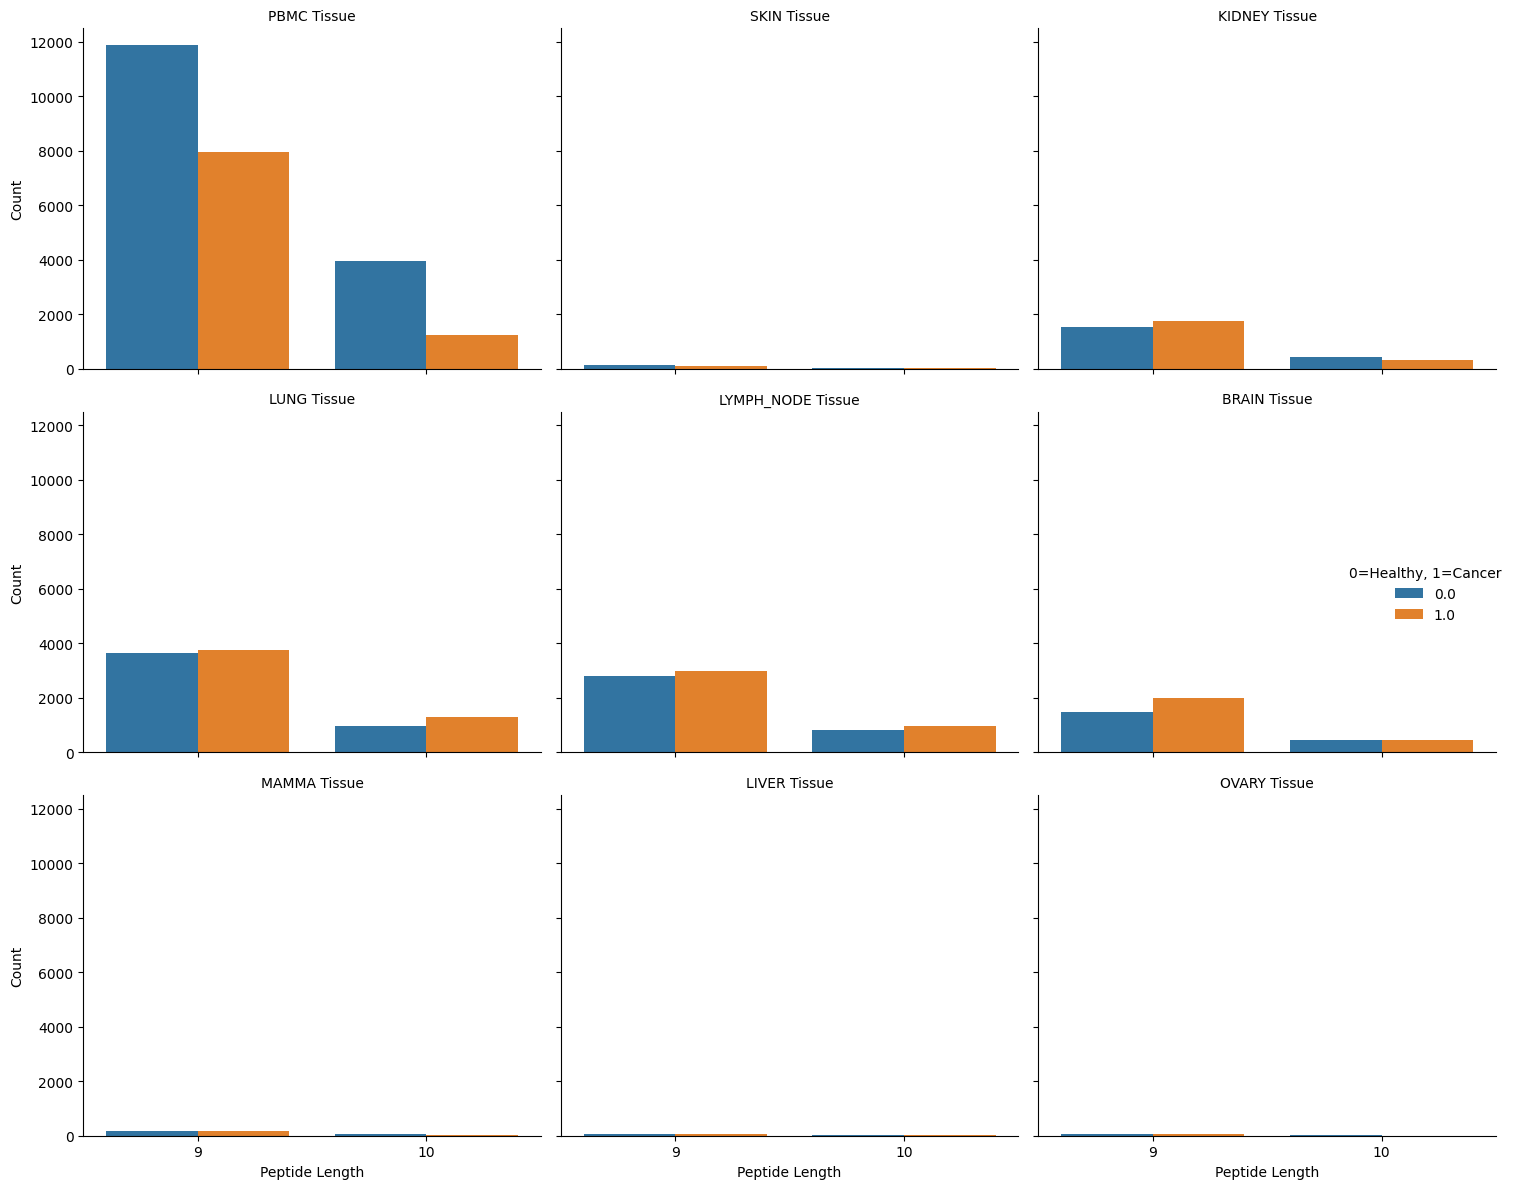

In [17]:
print("="*60)
print("1. TISSUE-LEVEL LENGTH COMPARISON (Percentage %)")
print("="*60)

# Calculate the percentage of each length within each Tissue & Class
# This normalizes the data so we can compare Healthy vs Cancer directly
counts = overall_df.groupby(['Tissue', 'is_cancer', 'length']).size().reset_index(name='count')
totals = counts.groupby(['Tissue', 'is_cancer'])['count'].transform('sum')
counts['pct'] = (counts['count'] / totals) * 100

# Pivot the table for easy reading
tissue_length_pct = counts.pivot_table(
    index=['Tissue', 'is_cancer'], 
    columns='length', 
    values='pct', 
    fill_value=0
).round(1)

# Rename the index for clarity (FIXED FOR NEWER PANDAS VERSIONS)
tissue_length_pct.index = tissue_length_pct.index.set_levels(['Healthy (0)', 'Cancer (1)'], level=1)
print(tissue_length_pct)


print("\n" + "="*60)
print("2. DISEASE-LEVEL ANOMALY CHECK (Cancer Only vs Tissue Baseline)")
print("="*60)

# Here we check if specific diseases are violating their tissue's healthy baseline
disease_counts = overall_df[overall_df['is_cancer'] == 1].groupby(['Tissue', 'Disease', 'length']).size().reset_index(name='count')
disease_totals = disease_counts.groupby(['Tissue', 'Disease'])['count'].transform('sum')
disease_counts['pct'] = (disease_counts['count'] / disease_totals) * 100

disease_length_pct = disease_counts.pivot_table(
    index=['Tissue', 'Disease'], 
    columns='length', 
    values='pct', 
    fill_value=0
).round(1)

print("Percentage of Peptide Lengths per Disease:")
print(disease_length_pct)


print("\n" + "="*60)
print("3. VISUALIZING TISSUE BALANCE (Top 11 Tissues)")
print("="*60)

# Get the top 11 tissues by total peptide count to visualize
top_tissues = overall_df['Tissue'].value_counts().head(11).index.tolist()
plot_df = overall_df[overall_df['Tissue'].isin(top_tissues)]

# Create a grid of bar charts
g = sns.catplot(
    data=plot_df, 
    x='length', 
    hue='is_cancer', 
    col='Tissue', 
    col_wrap=3, 
    kind='count', 
    height=4, 
    aspect=1.2,
    palette=['#1f77b4', '#ff7f0e']
)

# Clean up the chart titles and labels
g.set_titles("{col_name} Tissue")
g.set_axis_labels("Peptide Length", "Count")
g._legend.set_title("0=Healthy, 1=Cancer")
plt.tight_layout()
plt.show()

In [29]:
print(overall_df.columns)

Index(['Peptide Sequence', 'Best HLA Allele', 'Tissue', 'Disease', 'length',
       'molecular_weight', 'charge_pH_7', 'hydrophobicity_GRAVY',
       'isoelectric_point', 'source', 'hla_population_freq', 'aromaticity',
       'instability_index', 'helix_fraction', 'sheet_fraction',
       'turn_fraction', 'aliphatic_index', 'boman_index',
       'tcr_contact_hydro_mean', 'tcr_aromatic_count', 'tcr_hydrophobic_count',
       'has_tryptophan', 'tryptophan_at_tcr_pos', 'hydrophobic_fraction',
       'has_aromatic_central', 'is_9mer', 'length_class', 'aa_pct_A',
       'aa_pct_C', 'aa_pct_D', 'aa_pct_E', 'aa_pct_F', 'aa_pct_G', 'aa_pct_H',
       'aa_pct_I', 'aa_pct_K', 'aa_pct_L', 'aa_pct_M', 'aa_pct_N', 'aa_pct_P',
       'aa_pct_Q', 'aa_pct_R', 'aa_pct_S', 'aa_pct_T', 'aa_pct_V', 'aa_pct_W',
       'aa_pct_Y', 'is_cancer', 'found_in_healthy', 'strat_key'],
      dtype='object')


In [18]:
columns_to_drop = [
    # --- Identifiers & Raw Text (Breaks XGBoost/RF) --- # String: Keep a separate copy of this if you need to track predictions, but drop from X_train
    'Disease',            # String: Keep a separate copy of this if you need to track predictions, but drop from X_train
    'Best HLA Allele',    
    'source',             
    'length_class',       
    
    'hla_population_freq',
    'found_in_healthy',   
    'strat_key',          
]


overall_df = overall_df.drop(columns=columns_to_drop, errors='ignore')

print(f"Remaining columns: {len(overall_df.columns)}")

Remaining columns: 43


In [21]:
print(overall_df.head())

overall_df.to_csv("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/Final/mhc_class_I.csv")

  Peptide Sequence Tissue  length  molecular_weight  charge_pH_7  \
0        KYARVVQKL   PBMC       9         1104.3455     2.757095   
1        ALLETVNRL   PBMC       9         1028.2032    -0.201325   
2        MGLLPGALL   SKIN       9          884.1374    -0.499645   
3        LADAINTEF   PBMC       9          993.0680    -2.235967   
4       ILEEGKEILV   PBMC      10         1142.3423    -2.232466   

   hydrophobicity_GRAVY  isoelectric_point  aromaticity  instability_index  \
0             -0.344444          10.289686     0.111111          25.766667   
1              0.577778           6.047009     0.000000           8.888889   
2              1.833333           5.275022     0.000000          20.855556   
3              0.388889           4.050028     0.111111          11.422222   
4              0.600000           4.252659     0.000000          90.890000   

   helix_fraction  ...  aa_pct_N  aa_pct_P  aa_pct_Q  aa_pct_R  aa_pct_S  \
0        0.444444  ...  0.000000  0.000000  0.

In [59]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler  
import numpy as np
from Bio.Align import substitution_matrices


In [20]:

matrix = substitution_matrices.load("BLOSUM62")

def encode_peptide_to_blosum(sequence):
    encoded_vectors = []
    
    # Standard 20 amino acids (and occasionally B, Z, X mapped naturally depending on matrix)
    alphabet = "ARNDCQEGHILKMFPSTWYV"
    
    for aa in sequence.upper():
        if aa not in alphabet:
            aa = 'X' # Or handle unknown residues appropriately
            
        # Extract similarity scores for this amino acid against the alphabet
        vector = []
        for ref_aa in alphabet:
            try:
                score = matrix[(aa, ref_aa)]
            except KeyError:
                score = matrix.get((ref_aa, aa), -4) # Default mismatch penalty
            vector.append(score)
            
        encoded_vectors.append(vector)
        
    return encoded_vectors

In [26]:
peptide = overall_df['Peptide Sequence'].iloc[1000]
blosum_encoded = encode_peptide_to_blosum(peptide)

print(f"Peptide: {peptide}")
# print(f"BLOSUM Encoded: {blosum_encoded}")

for row in blosum_encoded:
    print(row)


Peptide: THALRTTEY
[0.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, -2.0, -2.0, -1.0, -1.0, -1.0, -1.0, -2.0, -1.0, 1.0, 5.0, -2.0, -2.0, 0.0]
[-2.0, 0.0, 1.0, -1.0, -3.0, 0.0, 0.0, -2.0, 8.0, -3.0, -3.0, -1.0, -2.0, -1.0, -2.0, -1.0, -2.0, -2.0, 2.0, -3.0]
[4.0, -1.0, -2.0, -2.0, 0.0, -1.0, -1.0, 0.0, -2.0, -1.0, -1.0, -1.0, -1.0, -2.0, -1.0, 1.0, 0.0, -3.0, -2.0, 0.0]
[-1.0, -2.0, -3.0, -4.0, -1.0, -2.0, -3.0, -4.0, -3.0, 2.0, 4.0, -2.0, 2.0, 0.0, -3.0, -2.0, -1.0, -2.0, -1.0, 1.0]
[-1.0, 5.0, 0.0, -2.0, -3.0, 1.0, 0.0, -2.0, 0.0, -3.0, -2.0, 2.0, -1.0, -3.0, -2.0, -1.0, -1.0, -3.0, -2.0, -3.0]
[0.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, -2.0, -2.0, -1.0, -1.0, -1.0, -1.0, -2.0, -1.0, 1.0, 5.0, -2.0, -2.0, 0.0]
[0.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, -2.0, -2.0, -1.0, -1.0, -1.0, -1.0, -2.0, -1.0, 1.0, 5.0, -2.0, -2.0, 0.0]
[-1.0, 0.0, 0.0, 2.0, -4.0, 2.0, 5.0, -2.0, 0.0, -3.0, -3.0, 1.0, -2.0, -3.0, -1.0, 0.0, -1.0, -3.0, -2.0, -2.0]
[-2.0, -2.0, -2.0, -3.0, -2.0, -1.0, -2.0, -3.0, 2.0, -1.0,

In [ ]:
'''

You can use ESM fold to quickly fold peptide seqeuneces with their MHC complex (HLA allele)

Downside is I would need to redo the dataset to ensure normalization of HLA alleles and recreating my dataset,

'''

# Test number one is using a method like Rdkit to convert the model into smalelr graphs first. 



In [ ]:
# 3




In [29]:
# PyTorch versions!!!

# 1. Position encoding with BLOSUM62 and anchor position weightage. 

ALPHABET = "ARNDCQEGHILKMFPSTWYV"
_matrix = substitution_matrices.load("BLOSUM62")
 
def encode_peptide_to_blosum(sequence: str) -> torch.Tensor:
    vectors = [] # Defines a list to hold the BLOSUM vectors for each amino acid in the sequence
    for aa in sequence.upper():  #loops thorugh the amino acids in the input sequence, converting them to uppercase to match the BLOSUM matrix keys
        vec = [] 
        for ref_aa in ALPHABET: #loops through the standard amino acids defined in the ALPHABET string, calculating the BLOSUM score for each pair of (aa, ref_aa)  
            try:
                score = _matrix[(aa, ref_aa)]
            except KeyError:
                score = _matrix.get((ref_aa, aa), -4)
            vec.append(float(score))
        vectors.append(vec)
    return torch.tensor(vectors, dtype=torch.float32)  # shape: (L, 20)



def build_anchor_bias(seq_len: int,
                      mhc_anchor_strength: float = -2.0,
                      tcr_anchor_strength: float = +2.0) -> torch.Tensor:
    
    bias = torch.zeros(seq_len, seq_len)

    # MHC-facing anchor columns (all rows attend less to these positions)
    anchor_cols = {1, seq_len - 1}           # position 2 and C-term (0-indexed)
    for col in anchor_cols:
        if col < seq_len:
            bias[:, col] += mhc_anchor_strength
 
    # TCR-facing columns (all rows attend more to these positions)
    tcr_start = 2
    tcr_end   = min(seq_len - 2, 7)         # positions 3–7 (0-indexed: 2–6)
    for col in range(tcr_start, tcr_end + 1):
        bias[:, col] += tcr_anchor_strength
 
    return bias  # (seq_len, seq_len)
 

# Testing

peptide = overall_df['Peptide Sequence'].iloc[1000]
blosum_encoded = encode_peptide_to_blosum(peptide)
anchor_bias = build_anchor_bias(len(peptide))

print(f"Peptide: {peptide}"
      f"\nBLOSUM Encoded Shape: {blosum_encoded.shape}"
      f"\nAnchor Bias Shape: {anchor_bias.shape}")

for i in range(min(5, blosum_encoded.shape[0])):
    print(f"Position {i+1} BLOSUM Vector: {blosum_encoded[i].tolist()}")    

for x in range(min(5, anchor_bias.shape[0])):
    print(f"Position {x+1} Anchor Bias: {anchor_bias[x].tolist()}")
    

Peptide: THALRTTEY
BLOSUM Encoded Shape: torch.Size([9, 20])
Anchor Bias Shape: torch.Size([9, 9])
Position 1 BLOSUM Vector: [0.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, -2.0, -2.0, -1.0, -1.0, -1.0, -1.0, -2.0, -1.0, 1.0, 5.0, -2.0, -2.0, 0.0]
Position 2 BLOSUM Vector: [-2.0, 0.0, 1.0, -1.0, -3.0, 0.0, 0.0, -2.0, 8.0, -3.0, -3.0, -1.0, -2.0, -1.0, -2.0, -1.0, -2.0, -2.0, 2.0, -3.0]
Position 3 BLOSUM Vector: [4.0, -1.0, -2.0, -2.0, 0.0, -1.0, -1.0, 0.0, -2.0, -1.0, -1.0, -1.0, -1.0, -2.0, -1.0, 1.0, 0.0, -3.0, -2.0, 0.0]
Position 4 BLOSUM Vector: [-1.0, -2.0, -3.0, -4.0, -1.0, -2.0, -3.0, -4.0, -3.0, 2.0, 4.0, -2.0, 2.0, 0.0, -3.0, -2.0, -1.0, -2.0, -1.0, 1.0]
Position 5 BLOSUM Vector: [-1.0, 5.0, 0.0, -2.0, -3.0, 1.0, 0.0, -2.0, 0.0, -3.0, -2.0, 2.0, -1.0, -3.0, -2.0, -1.0, -1.0, -3.0, -2.0, -3.0]
Position 1 Anchor Bias: [0.0, -2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, -2.0]
Position 2 Anchor Bias: [0.0, -2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, -2.0]
Position 3 Anchor Bias: [0.0, -2.0, 2.0, 2.0, 2.0,